# Project Introduction

- Telecom company lose customersdue to churn, churn impacts revenue and retention of customer.

- Analyze customer behavior patterns, identify churn factors, generate business insights.

- Tools we used while analyzing chart and factors which impacting churns like  MySQL, SQL, python, Pandas, Matplotlib,and Jupyer Notebook.

- Workflow Summary :- Dataset → MySQL → SQL Analysis → pandas → Visualization → Business Insights.

# Import Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

# Connect MySQL with Python

In [15]:
connection = mysql.connector.connect(
    host='localhost',
    user='root',
    password='@Ltamashfrgn+1',
    database='customer_churn_analysis'
)

# Shows successfully connected with MySQL Database

In [16]:
print(connection)

# Data extraction from MySQL Database

In [36]:
query = """
SELECT *
FROM customer_churn
"""
df = pd.read_sql(query, connection)

C:\Users\altam\AppData\Local\Temp\ipykernel_22544\1441346635.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


# showed with full column

In [18]:
pd.set_option('display.max_columns', None)

# Understand and Analyze data

In [31]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

# Feature Engineering

In [21]:
cursor = connection.cursor()

In [34]:
query = """
alter table customer_churn
add column TenureGroup varchar(20)
"""

cursor.execute(query)

connection.commit()

In [37]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,None
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,None
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,None
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,None
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,None


In [38]:
query = """
update customer_churn
set TenureGroup = case
when Tenure <= 12 then "New Customer"
when Tenure>12 and Tenure<=48 then "Mid-Term Customer"
else "Long-Term Customer"
end
"""

cursor.execute(query)
connection.commit()

In [41]:
query = """
select * from customer_churn
"""

data = pd.read_sql(query, connection)
data.head()

C:\Users\altam\AppData\Local\Temp\ipykernel_22544\983801355.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, connection)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New Customer
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Mid-Term Customer
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New Customer
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Mid-Term Customer
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New Customer


# SQL Based Analysis and Visualisation

In [42]:
query = """
select
Contract,
((sum(case when Churn = 'yes' then 1 else 0 end)*100)/count(*)) as churned_percentage
 from customer_churn
 group by Contract
 """

contract_churn = pd.read_sql(query, connection)

C:\Users\altam\AppData\Local\Temp\ipykernel_22544\1268418488.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contract_churn = pd.read_sql(query, connection)


In [43]:
contract_churn.reset_index()

,index,Contract,churned_percentage
0,0,Month-to-month,42.7097
1,1,One year,11.2772
2,2,Two year,2.8487


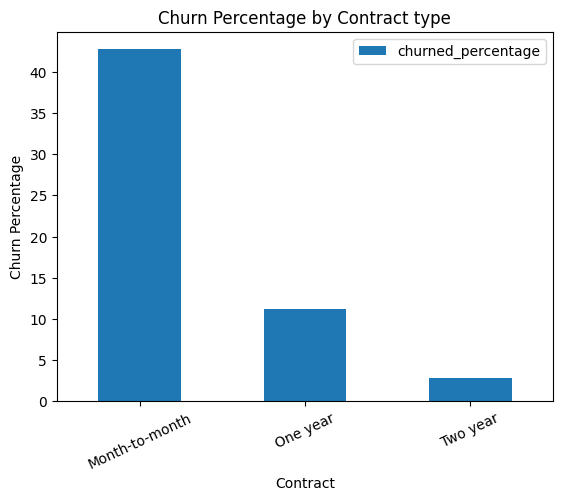

In [44]:
contract_churn.plot(
    x='Contract',
    y='churned_percentage',
    kind='bar'
)
plt.title('Churn Percentage by Contract type')
plt.xlabel('Contract')
plt.ylabel('Churn Percentage')
plt.xticks(rotation=25)
plt.show()



In [45]:
query = """
select TenureGroup,
((sum(case when Churn='Yes' then 1 else 0 end)*100)/count(*)) as churned_percentage
from customer_churn
group by TenureGroup
"""
tenuregroup_churn = pd.read_sql(query, connection)

C:\Users\altam\AppData\Local\Temp\ipykernel_22544\2412769427.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tenuregroup_churn = pd.read_sql(query, connection)


In [46]:
tenuregroup_churn.reset_index()

,index,TenureGroup,churned_percentage
0,0,New Customer,47.6782
1,1,Mid-Term Customer,23.6440
2,2,Long-Term Customer,9.5132


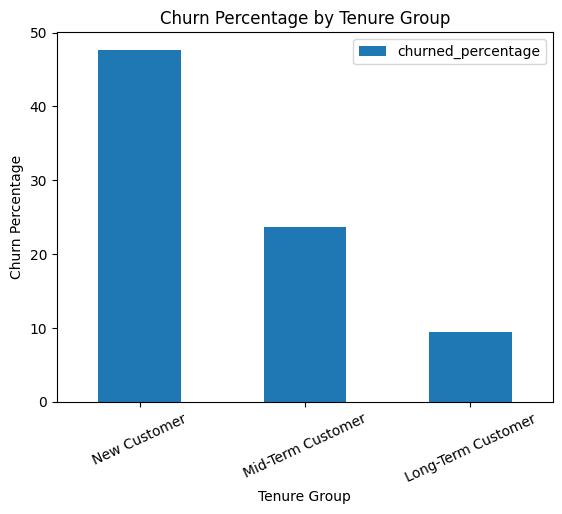

In [47]:
tenuregroup_churn.plot(
    x='TenureGroup',
    y='churned_percentage',
    kind='bar'
)

plt.title('Churn Percentage by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Percentage')
plt.xticks(rotation=25)
plt.show()

In [48]:
query = """
select Contract, InternetService,
((sum(case when Churn='Yes' then 1 else 0 end)*100)/count(*)) as churned_percentage
from customer_churn
group by Contract, InternetService
"""
contract_internet_churn = pd.read_sql(query, connection)

contract_internet_churn['segment'] = contract_internet_churn['Contract'] + '|' + contract_internet_churn['InternetService']

C:\Users\altam\AppData\Local\Temp\ipykernel_22544\925361849.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contract_internet_churn = pd.read_sql(query, connection)


In [49]:
contract_internet_churn.reset_index()
contract_internet_churn = contract_internet_churn.sort_values(by='churned_percentage', ascending=False)

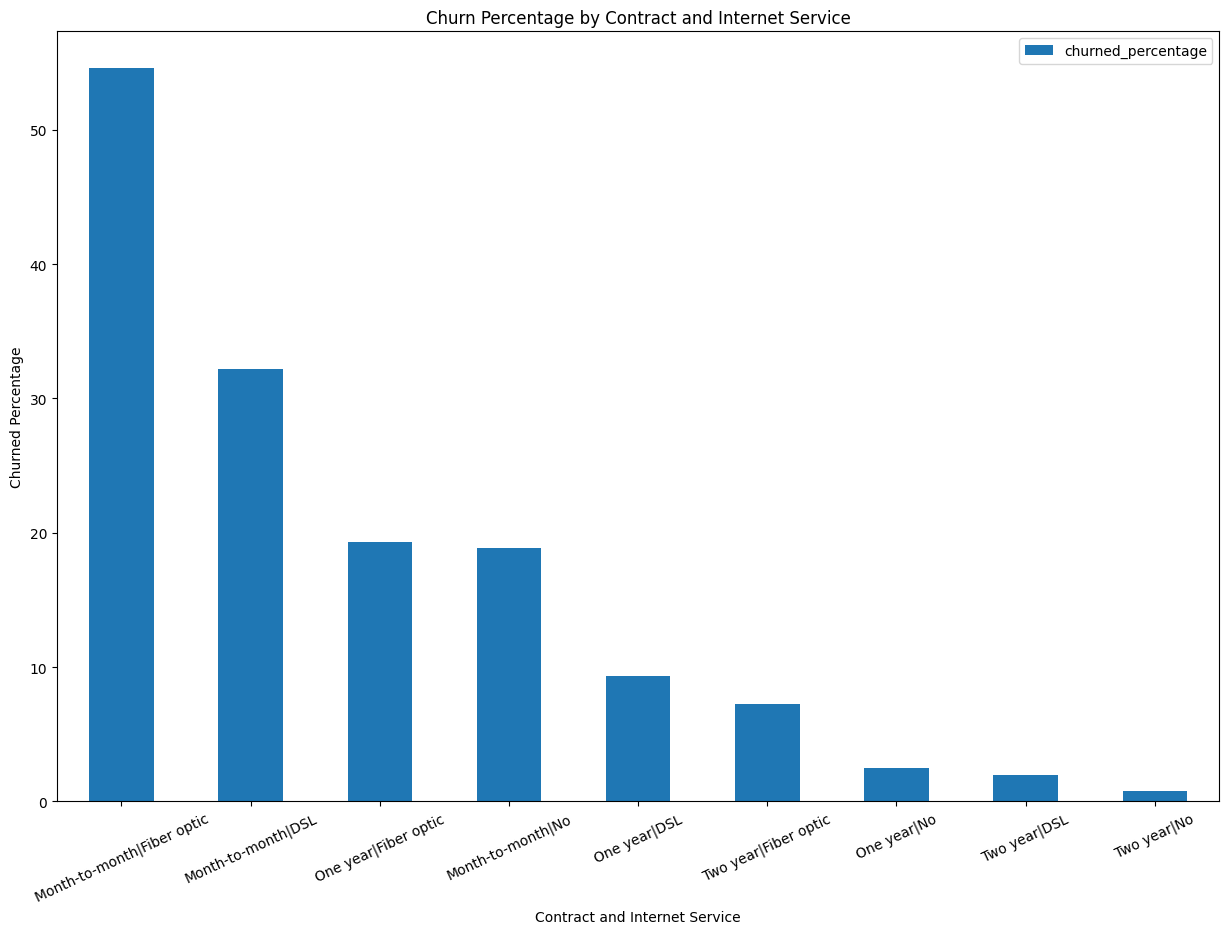

In [50]:
contract_internet_churn.plot(
    x='segment',
    y='churned_percentage',
    kind='bar',
    figsize=(15,10)
)
plt.title('Churn Percentage by Contract and Internet Service')
plt.xlabel('Contract and Internet Service')
plt.ylabel('Churned Percentage')
plt.xticks(rotation=25)
plt.show()

In [51]:
query = """
select PaymentMethod, Contract,
((sum(case when Churn='Yes' then 1 else 0 end)*100)/count(*)) as churned_percentage
from customer_churn
group by PaymentMethod, Contract
"""
payment_contract_churn = pd.read_sql(query, connection)
payment_contract_churn['segment'] = payment_contract_churn['PaymentMethod'] + ' | ' + payment_contract_churn['Contract']

# payment_contract_churn.reset_index()
payment_contract_churn = payment_contract_churn.sort_values(by='churned_percentage', ascending=False)

payment_contract_churn

C:\Users\altam\AppData\Local\Temp\ipykernel_22544\4021449030.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  payment_contract_churn = pd.read_sql(query, connection)


,PaymentMethod,Contract,churned_percentage,segment
0,Electronic check,Month-to-month,53.7297,Electronic check | Month-to-month
7,Bank transfer (automatic),Month-to-month,34.1256,Bank transfer (automatic) | Month-to-month
4,Credit card (automatic),Month-to-month,32.7808,Credit card (automatic) | Month-to-month
2,Mailed check,Month-to-month,31.5789,Mailed check | Month-to-month
9,Electronic check,One year,18.4438,Electronic check | One year
6,Credit card (automatic),One year,10.3015,Credit card (automatic) | One year
3,Bank transfer (automatic),One year,9.7187,Bank transfer (automatic) | One year
11,Electronic check,Two year,7.7381,Electronic check | Two year
1,Mailed check,One year,6.8452,Mailed check | One year
8,Bank transfer (automatic),Two year,3.3808,Bank transfer (automatic) | Two year


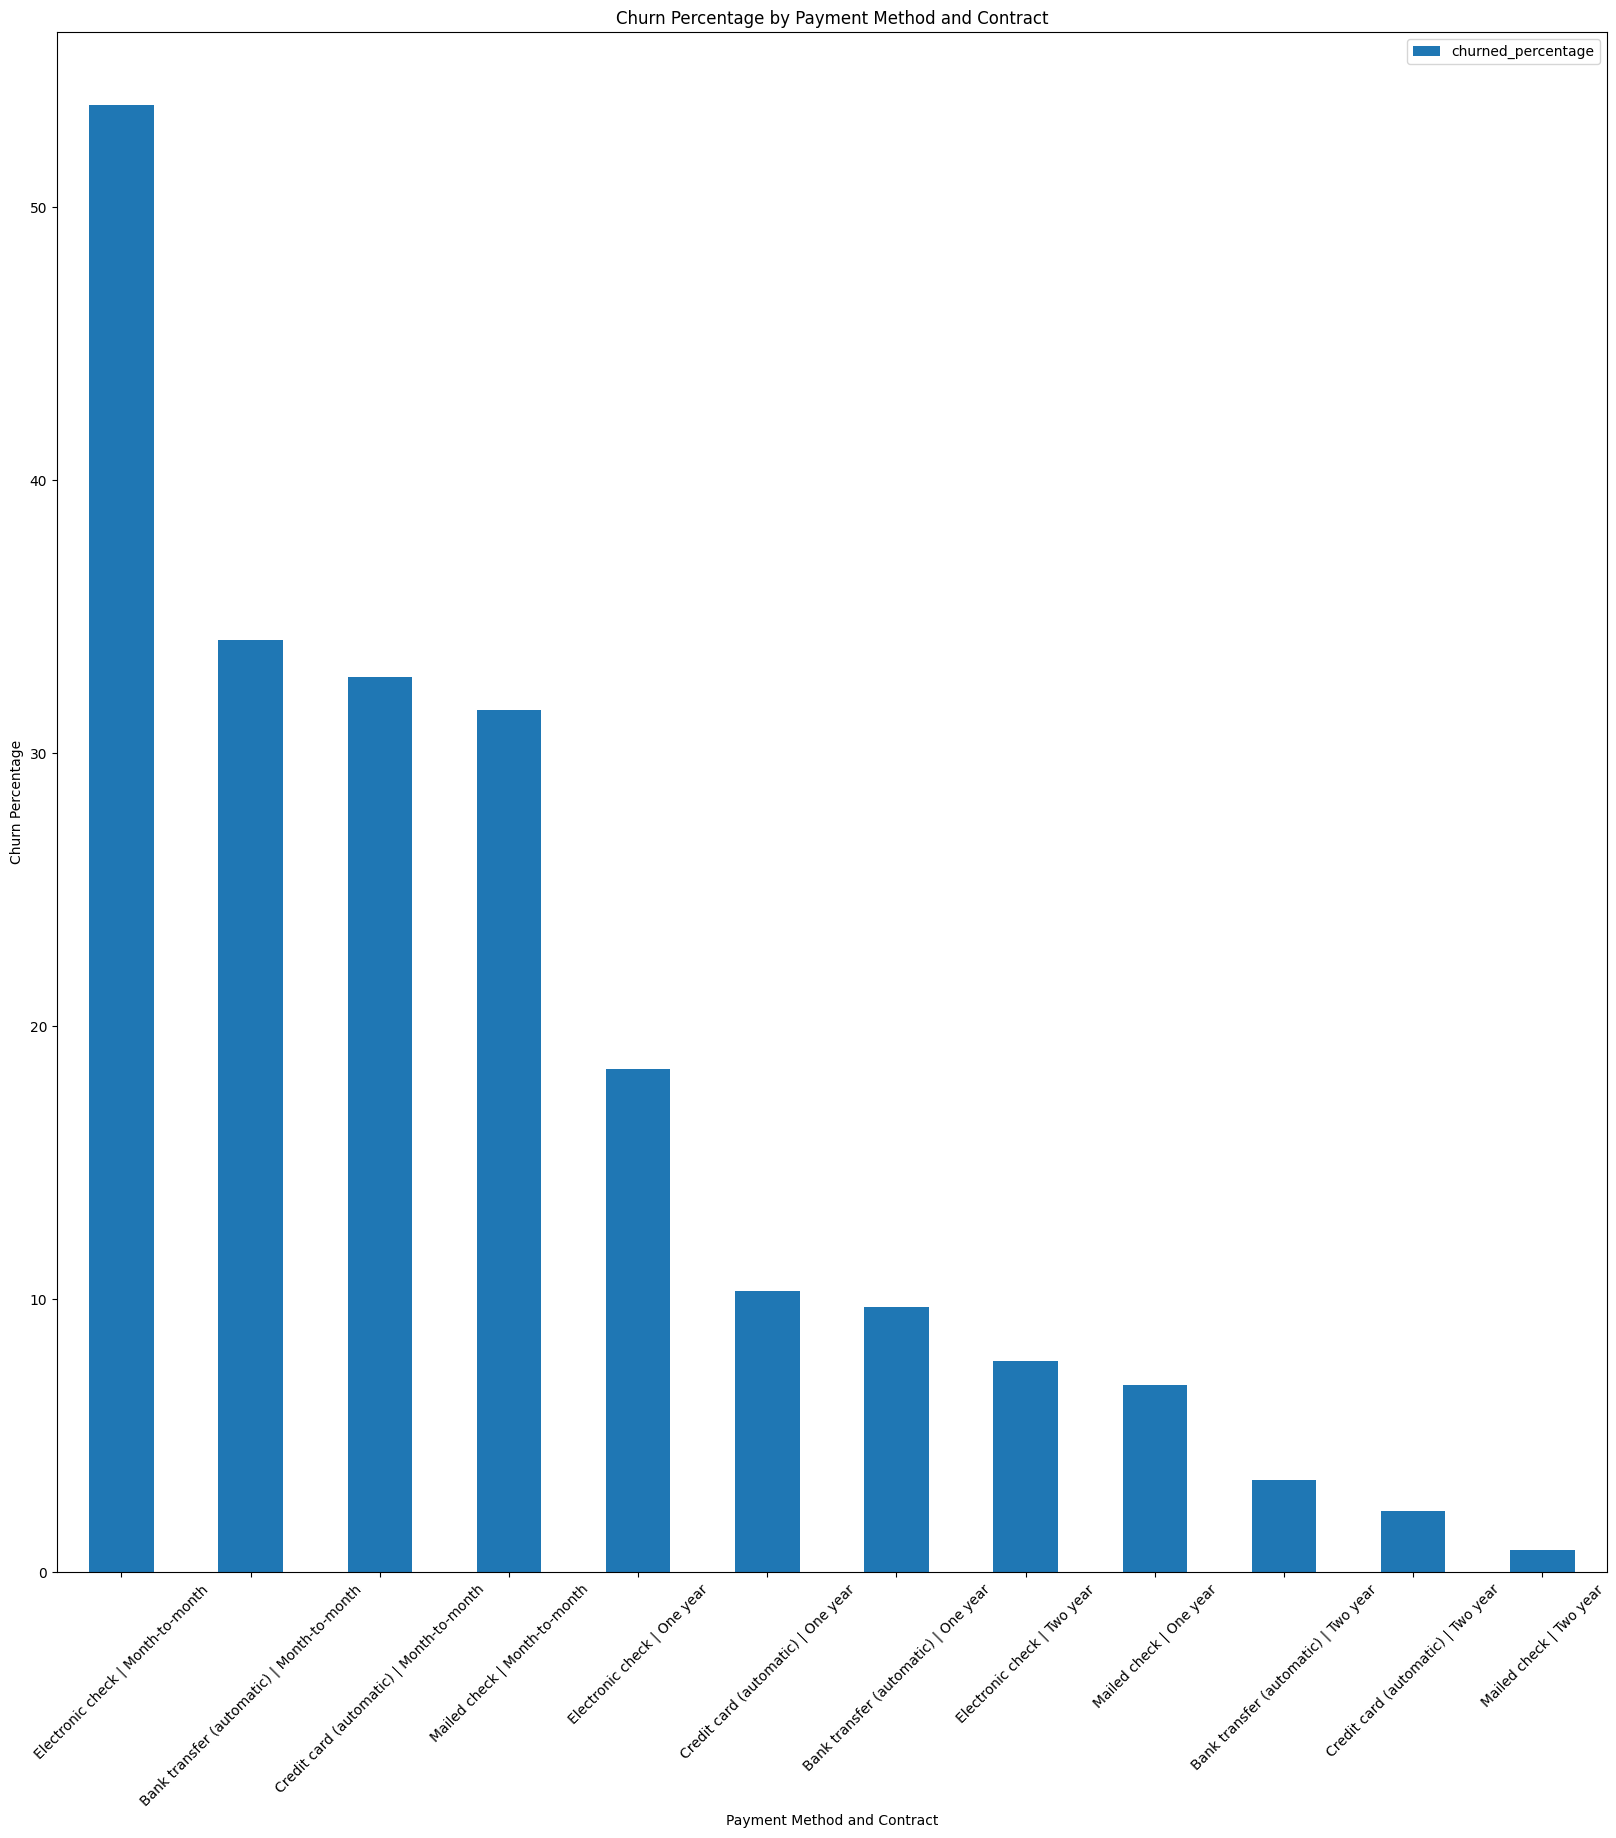

In [53]:
payment_contract_churn.plot(
    x = 'segment',
    y = 'churned_percentage',
    kind='bar',
    figsize=(20,20)
)
plt.title('Churn Percentage by Payment Method and Contract')
plt.xlabel('Payment Method and Contract')
plt.ylabel('Churn Percentage')
plt.xticks(rotation=45)
plt.show()

# Business Insghts & Recommendations

- Promote long-term contracts through discounts/incentives

- Improve onboarding and retention for new customers

- Investigate fiber optic customer dissatisfaction

- Encourage automatic payment methods

- Target high-risk segments like month-to-month fiber optic users with retention campaigns